In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [2]:
def plot_image(image1, image2, title1="Original Image", title2="Transformed Image"):
    plt.figure(figsize=(5,10))
    plt.subplot(1,2,1)
    plt.imshow(image1)
    plt.title(title1)
    plt.subplot(1,2,2)
    plt.imshow(image2)
    plt.title(title2)
    plt.show()


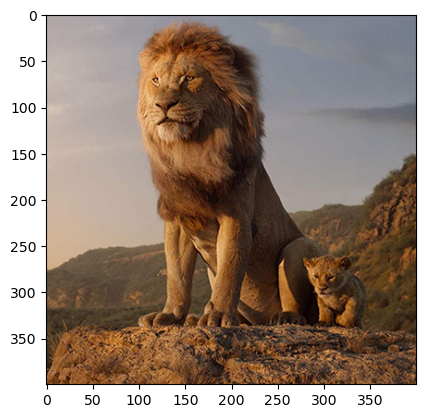

In [3]:
image=Image.open("simba.jpg")
plt.imshow(image)
plt.show()

In [4]:
width, height = image.size
print(width)
print(height)

400
400


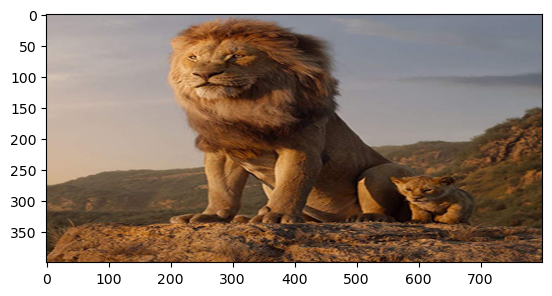

In [5]:
new_width=2*width
new_height=height
new_image = image.resize((new_width, new_height))
plt.imshow(new_image)
plt.show()

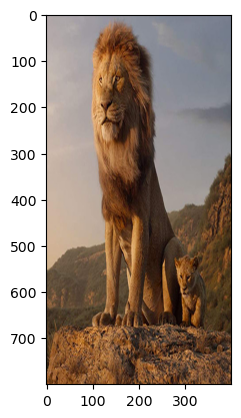

In [6]:
new_width=width
new_height=2*height
new_image = image.resize((new_width, new_height))
plt.imshow(new_image)
plt.show()

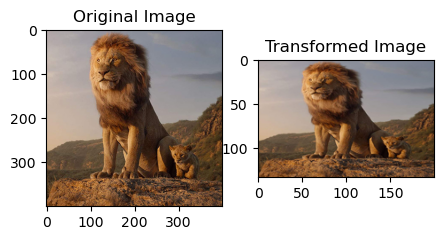

In [7]:
new_width=width//2
new_height=height//3
new_image = image.resize((new_width, new_height))
plot_image(image, new_image)

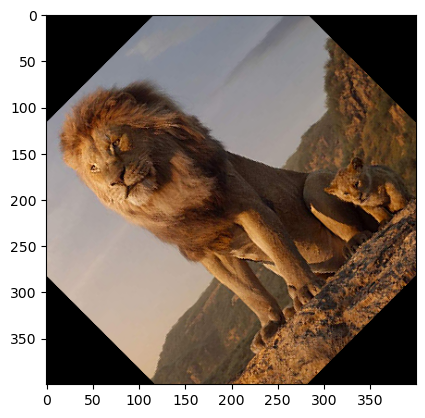

In [8]:
theta=45
new_image=image.rotate(theta)
plt.imshow(new_image)
plt.show()

## Mathematical Operations

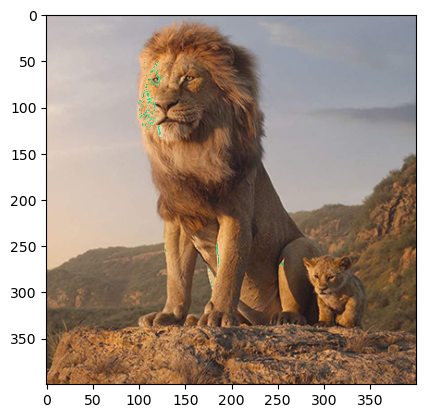

In [9]:
image = np.array(image)
new_image = image+20
plt.imshow(new_image)
plt.show()

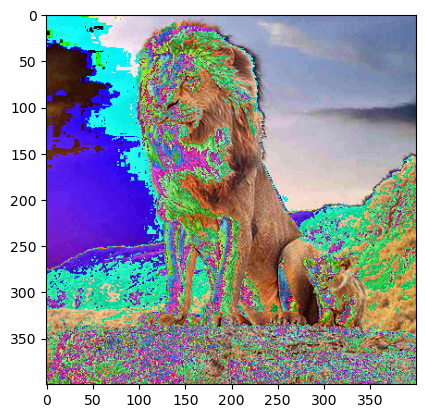

In [10]:
new_image = image*3
plt.imshow(new_image)
plt.show()

In [11]:
image.shape

(400, 400, 3)

In [12]:
Noise = np.random.normal(0,20, image.shape).astype(np.uint8)
Noise.shape

(400, 400, 3)

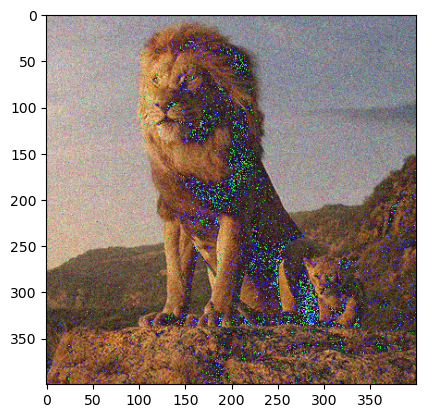

In [13]:
new_image = image + Noise
plt.imshow(new_image)

In [14]:
type(Noise)

numpy.ndarray

### Matrix Ops

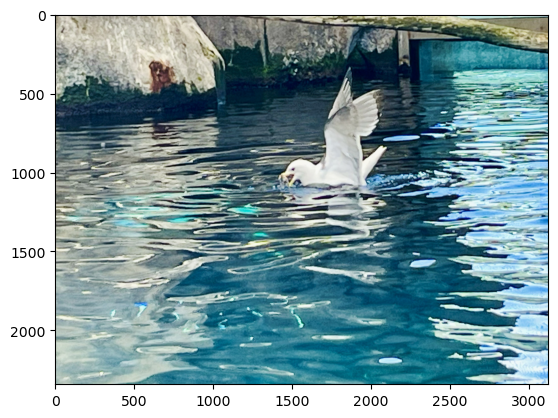

In [15]:
im_gray = Image.open("IMG_7574.jpg")
plt.imshow(im_gray)

In [16]:
im_gray.size

(3123, 2342)

In [17]:
from PIL import ImageOps

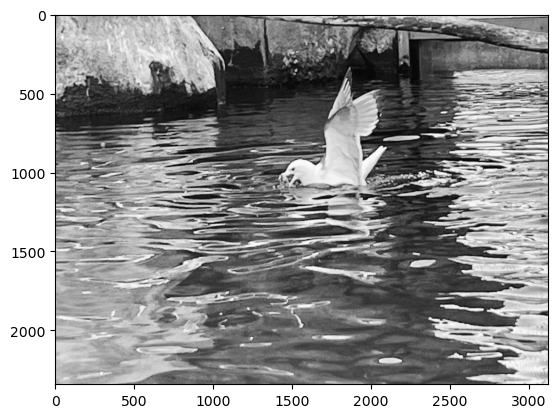

In [18]:
im_gray = ImageOps.grayscale(im_gray)
type(im_gray)
plt.imshow(im_gray, cmap="grey")

In [19]:
im_gray=np.array(im_gray)
type(im_gray)

numpy.ndarray

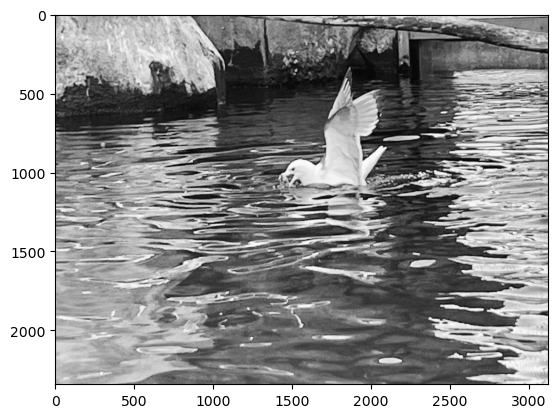

In [20]:
plt.imshow(im_gray, cmap="gray")

In [38]:
im_gray

array([[153, 153, 154, ..., 180, 180, 180],
       [153, 153, 154, ..., 182, 182, 181],
       [154, 154, 154, ..., 184, 184, 184],
       ...,
       [159, 161, 165, ..., 239, 237, 233],
       [154, 157, 161, ..., 239, 236, 231],
       [151, 154, 158, ..., 239, 235, 230]], dtype=uint8)

In [33]:
U, s, V = np.linalg.svd(im_gray)

In [34]:
print(U.shape)
print(s.shape)
print(V.shape)

(2342, 2342)
(2342,)
(3123, 3123)


In [35]:
# Create a diagonal matrix from the singular values
S = np.hstack([np.diag(s), np.zeros((U.shape[1], (V.shape[1]-U.shape[1])))])
# Reconstruct the original matrix
im_reconstructed = U @ S @ V

In [42]:
np.max(im_reconstructed-im_gray)

1.5626255844836123e-10

In [43]:
np.min(im_reconstructed-im_gray)

-2.1435653252410702e-10

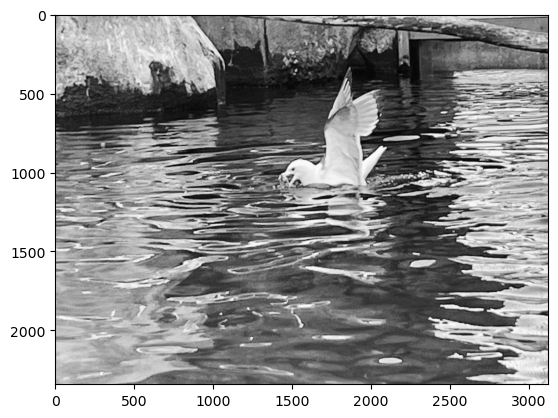

In [46]:
im_reconstructed = im_reconstructed.astype(np.uint8)
plt.imshow(im_reconstructed, cmap="gray")